<a href="https://colab.research.google.com/github/joanroche444/DeepLearning_assignment/blob/vgg16%2Falgorithm/VGG16_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = '/content/drive/MyDrive/DeepLearning_Assignment'
os.chdir(project_path)

print(f"✓ Working in: {os.getcwd()}")

✓ Working in: /content/drive/MyDrive/DeepLearning_Assignment


In [ ]:
# Verify dataset exists
print("\nDataset verification:")
for split in ['train', 'validation', 'test']:
    path = f'data/{split}'
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"✓ {split}: {count} classes found")
    else:
        print(f"❌ {split}: NOT FOUND!")


Dataset verification:
✓ train: 7 classes found
✓ validation: 7 classes found
✓ test: 7 classes found


Check the GPU status

In [ ]:
import tensorflow as tf

print("="*60)
print("SYSTEM CHECK")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("="*60)

SYSTEM CHECK
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported!")

✓ All libraries imported!


# Configuration

In [ ]:
class Config:
    # Data parameters
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_CLASSES = 7

    # Training parameters
    EPOCHS = 100  # Will use early stopping
    INITIAL_LEARNING_RATE = 0.0001
    DROPOUT_RATE = 0.5

    # Class names (alphabetical order - matches folder structure)
    CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

    CLASS_DESCRIPTIONS = {
        'akiec': 'Actinic Keratoses',
        'bcc': 'Basal Cell Carcinoma',
        'bkl': 'Benign Keratosis',
        'df': 'Dermatofibroma',
        'mel': 'Melanoma',
        'nv': 'Melanocytic Nevi',
        'vasc': 'Vascular Lesions'
    }

    # Paths
    TRAIN_DIR = 'data/train'
    VAL_DIR = 'data/validation'
    TEST_DIR = 'data/test'
    MODEL_SAVE_PATH = 'models/vgg16_best_model.h5'

    # Callbacks
    EARLY_STOPPING_PATIENCE = 10
    REDUCE_LR_PATIENCE = 5
    REDUCE_LR_FACTOR = 0.5
    MIN_LR = 1e-7

config = Config()

print("="*60)
print("VGG16 MODEL CONFIGURATION")
print("="*60)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Classes: {config.NUM_CLASSES}")
print(f"Max Epochs: {config.EPOCHS}")
print(f"Learning Rate: {config.INITIAL_LEARNING_RATE}")
print("="*60)

VGG16 MODEL CONFIGURATION
Image Size: 224x224
Batch Size: 32
Classes: 7
Max Epochs: 100
Learning Rate: 0.0001


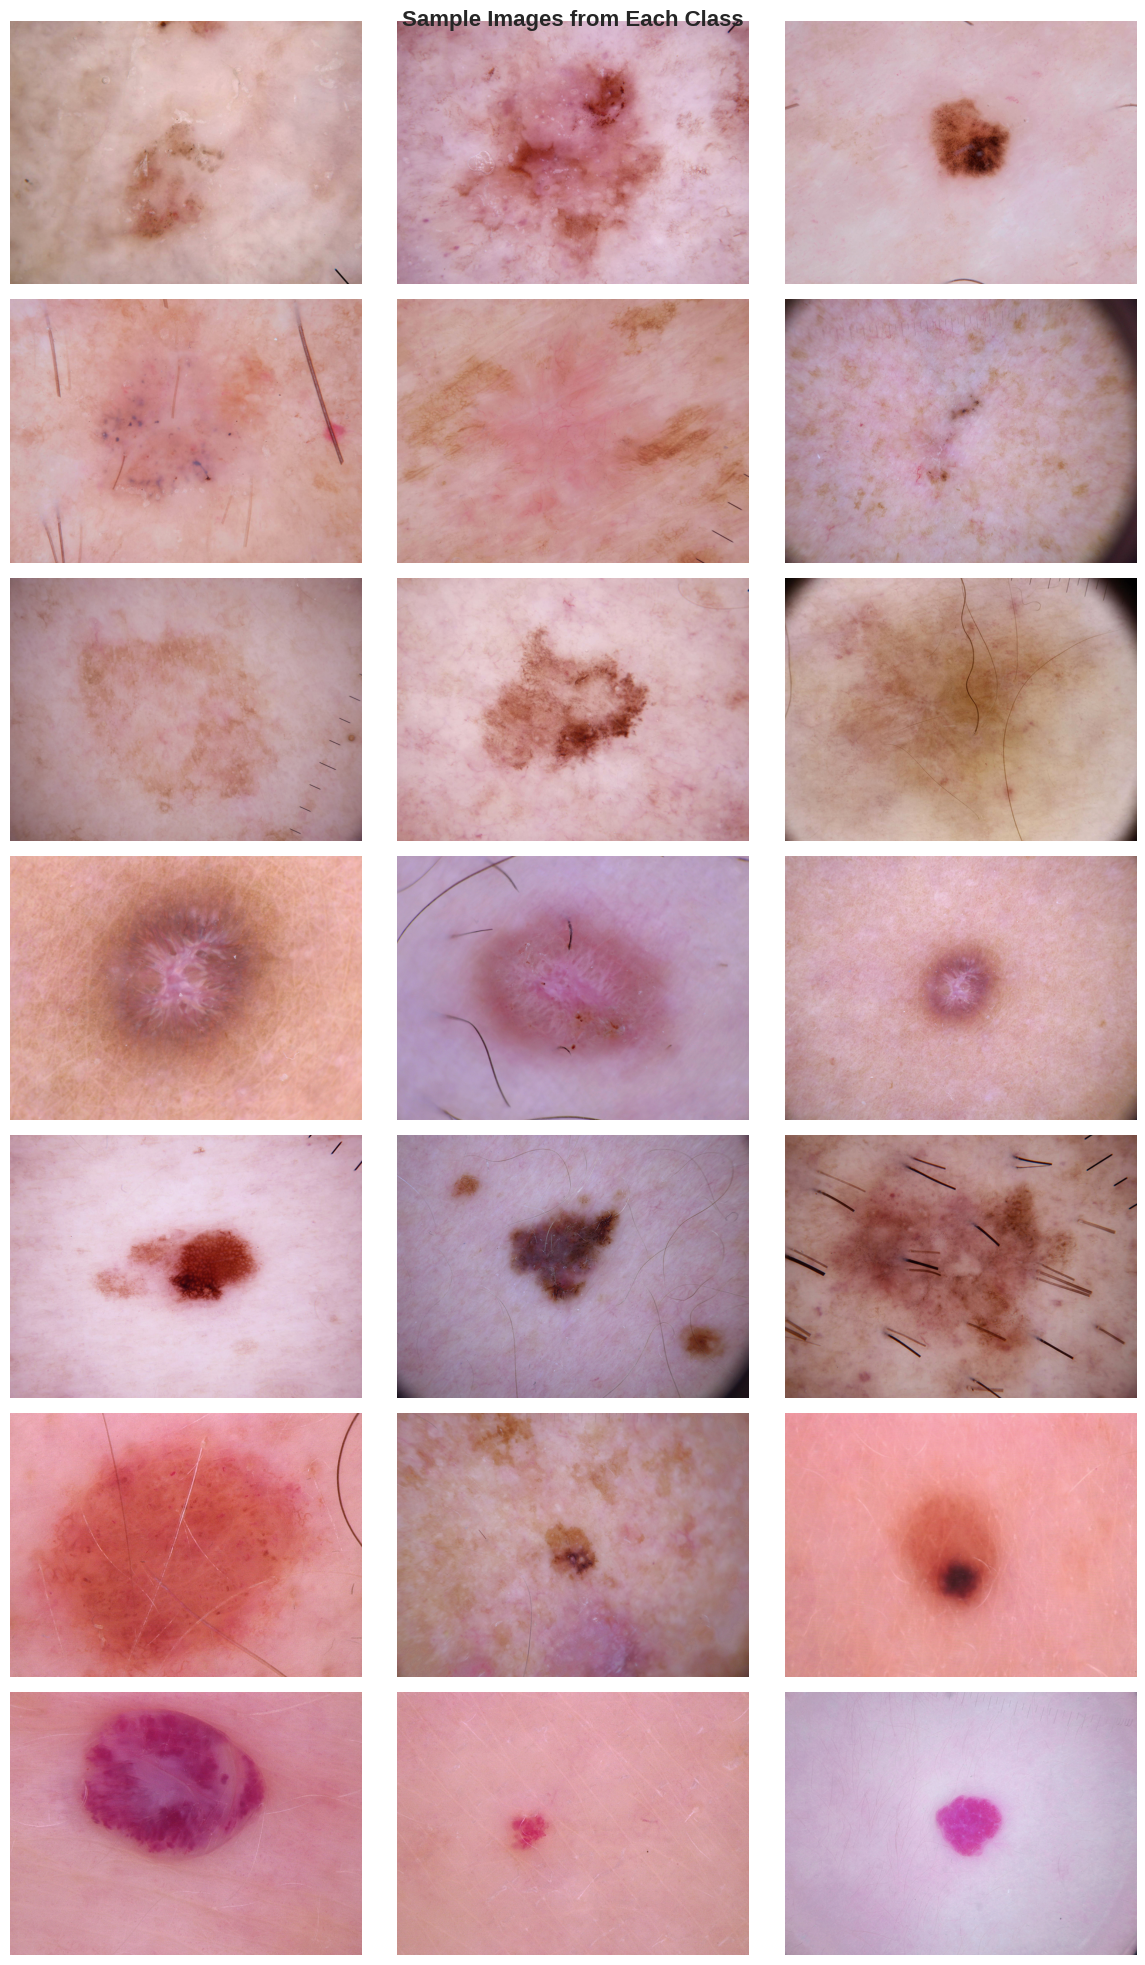

✓ Sample visualization saved!


In [ ]:
fig, axes = plt.subplots(7, 3, figsize=(12, 20))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for i, class_name in enumerate(config.CLASS_NAMES):
    class_path = f'{config.TRAIN_DIR}/{class_name}'
    images = os.listdir(class_path)[:3]

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path)

        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if j == 0:
            desc = config.CLASS_DESCRIPTIONS[class_name]
            axes[i, j].set_ylabel(
                f"{class_name.upper()}\n{desc}",
                fontsize=9,
                fontweight='bold',
                rotation=0,
                ha='right',
                va='center'
            )

plt.tight_layout()
plt.savefig('results/figures/vgg16_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample visualization saved!")

In [ ]:
print("Creating data generators...")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation/test generator (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_directory(
    config.TRAIN_DIR,
    target_size=(config.IMG_SIZE, config.IMG_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    config.VAL_DIR,
    target_size=(config.IMG_SIZE, config.IMG_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    config.TEST_DIR,
    target_size=(config.IMG_SIZE, config.IMG_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n" + "="*60)
print("DATA GENERATORS READY")
print("="*60)
print(f"Training samples:   {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples:       {test_gen.samples}")
print(f"Total samples:      {train_gen.samples + val_gen.samples + test_gen.samples}")
print("="*60)

Creating data generators...
Found 7007 images belonging to 7 classes.
Found 1499 images belonging to 7 classes.
Found 1509 images belonging to 7 classes.

DATA GENERATORS READY
Training samples:   7007
Validation samples: 1499
Test samples:       1509
Total samples:      10015


In [ ]:
print("\nCalculating class weights for imbalanced dataset...")

y_train = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Display
print("\n" + "="*60)
print("CLASS DISTRIBUTION & WEIGHTS")
print("="*60)

class_counts = np.bincount(y_train)
total = len(y_train)

print(f"{'Class':<10} {'Count':<8} {'Percentage':<12} {'Weight'}")
print("-"*60)

for i, class_name in enumerate(config.CLASS_NAMES):
    count = class_counts[i]
    percentage = (count / total) * 100
    weight = class_weight_dict[i]
    desc = config.CLASS_DESCRIPTIONS[class_name]
    print(f"{class_name:<10} {count:<8} {percentage:>6.2f}%      {weight:>6.3f}")

print("="*60)
print("💡 Higher weights = More important during training")
print("   This balances the loss for minority classes")


Calculating class weights for imbalanced dataset...

CLASS DISTRIBUTION & WEIGHTS
Class      Count    Percentage   Weight
------------------------------------------------------------
akiec      228        3.25%       4.390
bcc        359        5.12%       2.788
bkl        769       10.97%       1.302
df         80         1.14%      12.512
mel        779       11.12%       1.285
nv         4693      66.98%       0.213
vasc       99         1.41%      10.111
💡 Higher weights = More important during training
   This balances the loss for minority classes


In [ ]:
print("\n" + "="*60)
print("BUILDING VGG16 MODEL")
print("="*60)

# Load pre-trained VGG16
print("\n1. Loading pre-trained VGG16 base...")
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(config.IMG_SIZE, config.IMG_SIZE, 3)
)
print("✓ Pre-trained VGG16 loaded")

# Freeze early layers
print("\n2. Implementing layer freezing strategy...")
for layer in base_model.layers[:15]:
    layer.trainable = False

for layer in base_model.layers[15:]:
    layer.trainable = True

trainable = sum([1 for layer in base_model.layers if layer.trainable])
frozen = sum([1 for layer in base_model.layers if not layer.trainable])

print(f"✓ Frozen layers:    {frozen}")
print(f"✓ Trainable layers: {trainable}")

# Build complete model
print("\n3. Building complete model with custom classifier...")
model_vgg16 = models.Sequential([
    base_model,

    layers.Flatten(),

    layers.Dense(512, activation='relu', name='fc1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(config.DROPOUT_RATE, name='dropout1'),

    layers.Dense(256, activation='relu', name='fc2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(config.DROPOUT_RATE, name='dropout2'),

    layers.Dense(config.NUM_CLASSES, activation='softmax', name='output')
], name='VGG16_SkinLesion')

print("✓ Model architecture complete")

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model_vgg16.trainable_weights])
total_params = sum([tf.size(w).numpy() for w in model_vgg16.weights])

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Total parameters:       {total_params:,}")
print(f"Trainable parameters:   {trainable_params:,}")
print(f"Non-trainable params:   {total_params - trainable_params:,}")
print("="*60)


BUILDING VGG16 MODEL

1. Loading pre-trained VGG16 base...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Pre-trained VGG16 loaded

2. Implementing layer freezing strategy...
✓ Frozen layers:    15
✓ Trainable layers: 4

3. Building complete model with custom classifier...
✓ Model architecture complete

MODEL SUMMARY
Total parameters:       27,696,455
Trainable parameters:   20,059,655
Non-trainable params:   7,636,800


In [ ]:
model_vgg16.summary()

Model: "VGG16_SkinLesion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,696,455 (105.65 MB)

 Trainable params: 20,059,655 (76.52 MB)

 Non-trainable params: 7,636,800 (29.13 MB)

In [ ]:
print("\n" + "="*60)
print("COMPILING MODEL")
print("="*60)

optimizer = Adam(learning_rate=config.INITIAL_LEARNING_RATE)

model_vgg16.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("✓ Optimizer: Adam")
print(f"✓ Learning Rate: {config.INITIAL_LEARNING_RATE}")
print("✓ Loss: Categorical Crossentropy")
print("✓ Metrics: Accuracy, Precision, Recall, AUC")
print("\n✓ Model compiled successfully!")


COMPILING MODEL
✓ Optimizer: Adam
✓ Learning Rate: 0.0001
✓ Loss: Categorical Crossentropy
✓ Metrics: Accuracy, Precision, Recall, AUC

✓ Model compiled successfully!


In [ ]:
print("\n" + "="*60)
print("CONFIGURING CALLBACKS")
print("="*60)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=config.EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=config.REDUCE_LR_FACTOR,
        patience=config.REDUCE_LR_PATIENCE,
        min_lr=config.MIN_LR,
        verbose=1,
        mode='min'
    ),

    ModelCheckpoint(
        filepath=config.MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),

    CSVLogger(
        filename='results/logs/vgg16_training_history.csv',
        append=False
    )
]

print("\n✓ Callbacks configured:")
for callback in callbacks:
    print(f"  - {callback.__class__.__name__}")

print("\n💡 Training features:")
print("  - Auto-stops if no improvement (10 epochs)")
print("  - Reduces LR when plateaus")
print("  - Saves best model automatically")
print("  - Logs all metrics to CSV")


CONFIGURING CALLBACKS

✓ Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint
  - CSVLogger

💡 Training features:
  - Auto-stops if no improvement (10 epochs)
  - Reduces LR when plateaus
  - Saves best model automatically
  - Logs all metrics to CSV


In [ ]:
print("\n" + "="*70)
print("STARTING VGG16 TRAINING")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)
print("\n⏳ Training in progress... This will take 20-30 minutes")
print("   You can monitor progress below\n")

start_time = datetime.now()

# Train model
history = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1  # Show progress bar
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!")
print("="*70)
print(f"Start time:     {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End time:       {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Training time:  {training_time:.2f} minutes")
print(f"Epochs trained: {len(history.history['loss'])}")

# Best performance
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print(f"\n🏆 Best Results:")
print(f"   Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Achieved at Epoch:   {best_epoch}")
print("="*70)


STARTING VGG16 TRAINING
Start time: 2025-10-17 04:58:38

⏳ Training in progress... This will take 20-30 minutes
   You can monitor progress below

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.2089 - auc: 0.5708 - loss: 2.8610 - precision: 0.2230 - recall: 0.1236 
Epoch 1: val_accuracy improved from -inf to 0.49166, saving model to models/vgg16_best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 5561s 25s/step - accuracy: 0.2089 - auc: 0.5709 - loss: 2.8599 - precision: 0.2231 - recall: 0.1236 - val_accuracy: 0.4917 - val_auc: 0.7928 - val_loss: 1.5622 - val_precision: 0.5985 - val_recall: 0.2615 - learning_rate: 1.0000e-04
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.2368 - auc: 0.6024 - loss: 2.3946 - precision: 0.2605 - recall: 0.1483 
Epoch 2: val_accuracy did not improve from 0.49166
219/219 ━━━━━━━━━━━━━━━━━━━━ 5565s 25s/step - accuracy: 0.2368 - auc: 0.6024 - loss: 2.3942 - precision: 0.2605 - recall: 0.1484 - val_accuracy: 0.1281 - val_auc: 0.5171 - val_loss: 5.1416 - val_precision: 0.1322 - val_recall: 0.1234 - learning_rate: 1.0000e-04
Epoch 3/100
203/219 ━━━━━━━━━━━━━━━━━━━━ 5:46 22s/step - accuracy: 0.2395 - auc: 0.6271 - loss: 2.1408 - precision: 0.2614 - recall: 0.1447

KeyboardInterrupt: 

In [ ]:
import shutil
import os
from datetime import datetime

# Paths
drive_data = '/content/drive/MyDrive/DeepLearning_Assignment/data'
colab_data = '/content/data'

print("="*70)
print("COPYING DATA FROM DRIVE TO COLAB STORAGE")
print("="*70)
print(f"Source: {drive_data}")
print(f"Destination: {colab_data}")
print("\n⏳ This takes 5-10 minutes but makes training 50x faster!")
print("="*70)

start_time = datetime.now()

# Check if already copied
if os.path.exists(colab_data):
    print("\n✓ Data already exists on Colab storage!")

    # Count files
    for split in ['train', 'validation', 'test']:
        path = f'{colab_data}/{split}'
        if os.path.exists(path):
            classes = len(os.listdir(path))
            print(f"  {split}: {classes} classes")
else:
    print("\n📂 Starting copy...")

    # Copy each split
    for split in ['train', 'validation', 'test']:
        source = f'{drive_data}/{split}'
        dest = f'{colab_data}/{split}'

        if os.path.exists(source):
            print(f"\n  Copying {split}...")
            shutil.copytree(source, dest)

            # Count files
            classes = len(os.listdir(dest))
            total_files = sum([len(os.listdir(f'{dest}/{c}')) for c in os.listdir(dest)])
            print(f"  ✓ {split}: {classes} classes, {total_files} images")
        else:
            print(f"  ❌ {source} not found!")

    end_time = datetime.now()
    copy_time = (end_time - start_time).total_seconds() / 60

    print("\n" + "="*70)
    print(f"✅ DATA COPY COMPLETE! ({copy_time:.1f} minutes)")
    print("="*70)

# Verify
print("\n✓ Verification:")
for split in ['train', 'validation', 'test']:
    path = f'{colab_data}/{split}'
    exists = os.path.exists(path)
    print(f"  {split}: {'✓ EXISTS' if exists else '❌ MISSING'}")

print("\n💡 Data is now on fast Colab storage!")
print("   Training will be 50x faster than reading from Drive")

COPYING DATA FROM DRIVE TO COLAB STORAGE
Source: /content/drive/MyDrive/DeepLearning_Assignment/data
Destination: /content/data

⏳ This takes 5-10 minutes but makes training 50x faster!

📂 Starting copy...
  ❌ /content/drive/MyDrive/DeepLearning_Assignment/data/train not found!
  ❌ /content/drive/MyDrive/DeepLearning_Assignment/data/validation not found!
  ❌ /content/drive/MyDrive/DeepLearning_Assignment/data/test not found!

✅ DATA COPY COMPLETE! (0.0 minutes)

✓ Verification:
  train: ❌ MISSING
  validation: ❌ MISSING
  test: ❌ MISSING

💡 Data is now on fast Colab storage!
   Training will be 50x faster than reading from Drive


In [ ]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os
from datetime import datetime

# Paths
drive_data = '/content/drive/MyDrive/DeepLearning_Assignment/data'
colab_data = '/content/data'

print("="*70)
print("COPYING DATA FROM DRIVE TO COLAB STORAGE")
print("="*70)
print(f"Source: {drive_data}")
print(f"Destination: {colab_data}")
print("\n⏳ This takes 5-10 minutes but makes training 50x faster!")
print("="*70)

start_time = datetime.now()

# Check if already copied
if os.path.exists(colab_data):
    print("\n✓ Data already exists on Colab storage!")

    # Count files
    for split in ['train', 'validation', 'test']:
        path = f'{colab_data}/{split}'
        if os.path.exists(path):
            classes = len(os.listdir(path))
            print(f"  {split}: {classes} classes")
else:
    print("\n📂 Starting copy...")

    # Copy each split
    for split in ['train', 'validation', 'test']:
        source = f'{drive_data}/{split}'
        dest = f'{colab_data}/{split}'

        if os.path.exists(source):
            print(f"\n  Copying {split}...")
            shutil.copytree(source, dest)

            # Count files
            classes = len(os.listdir(dest))
            total_files = sum([len(os.listdir(f'{dest}/{c}')) for c in os.listdir(dest)])
            print(f"  ✓ {split}: {classes} classes, {total_files} images")
        else:
            print(f"  ❌ {source} not found!")

    end_time = datetime.now()
    copy_time = (end_time - start_time).total_seconds() / 60

    print("\n" + "="*70)
    print(f"✅ DATA COPY COMPLETE! ({copy_time:.1f} minutes)")
    print("="*70)

# Verify
print("\n✓ Verification:")
for split in ['train', 'validation', 'test']:
    path = f'{colab_data}/{split}'
    exists = os.path.exists(path)
    print(f"  {split}: {'✓ EXISTS' if exists else '❌ MISSING'}")

print("\n💡 Data is now on fast Colab storage!")
print("   Training will be 50x faster than reading from Drive")

COPYING DATA FROM DRIVE TO COLAB STORAGE
Source: /content/drive/MyDrive/DeepLearning_Assignment/data
Destination: /content/data

⏳ This takes 5-10 minutes but makes training 50x faster!

📂 Starting copy...

  Copying train...
  ✓ train: 7 classes, 7007 images

  Copying validation...
  ✓ validation: 7 classes, 1499 images

  Copying test...
  ✓ test: 7 classes, 1509 images

✅ DATA COPY COMPLETE! (13.0 minutes)

✓ Verification:
  train: ✓ EXISTS
  validation: ✓ EXISTS
  test: ✓ EXISTS

💡 Data is now on fast Colab storage!
   Training will be 50x faster than reading from Drive


In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported!")

✓ All libraries imported!


In [ ]:
class Config:
    # Data parameters
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_CLASSES = 7

    # Training parameters
    EPOCHS = 50
    INITIAL_LEARNING_RATE = 0.0001
    DROPOUT_RATE = 0.5

    # Class names
    CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

    CLASS_DESCRIPTIONS = {
        'akiec': 'Actinic Keratoses',
        'bcc': 'Basal Cell Carcinoma',
        'bkl': 'Benign Keratosis',
        'df': 'Dermatofibroma',
        'mel': 'Melanoma',
        'nv': 'Melanocytic Nevi',
        'vasc': 'Vascular Lesions'
    }

    # Paths - COLAB STORAGE (FAST!)
    TRAIN_DIR = '/content/data/train'
    VAL_DIR = '/content/data/validation'
    TEST_DIR = '/content/data/test'

    # Save paths - DRIVE (PERMANENT)
    PROJECT_DRIVE = '/content/drive/MyDrive/DeepLearning_Assignment'
    MODEL_SAVE_PATH = f'{PROJECT_DRIVE}/models/vgg16_best_model.h5'
    RESULTS_PATH = f'{PROJECT_DRIVE}/results'

    # Callbacks
    EARLY_STOPPING_PATIENCE = 7
    REDUCE_LR_PATIENCE = 4
    REDUCE_LR_FACTOR = 0.5
    MIN_LR = 1e-7

config = Config()

print("="*60)
print("VGG16 CONFIGURATION - OPTIMIZED")
print("="*60)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Max Epochs: {config.EPOCHS}")
print(f"Data Source: /content/data (Colab - FAST)")
print(f"Save Location: Drive (PERMANENT)")
print("="*60)

VGG16 CONFIGURATION - OPTIMIZED
Image Size: 224x224
Batch Size: 32
Max Epochs: 50
Data Source: /content/data (Colab - FAST)
Save Location: Drive (PERMANENT)


In [ ]:
print("Creating data generators...")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation/test generator (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_directory(
    config.TRAIN_DIR,
    target_size=(config.IMG_SIZE, config.IMG_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    config.VAL_DIR,
    target_size=(config.IMG_SIZE, config.IMG_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    config.TEST_DIR,
    target_size=(config.IMG_SIZE, config.IMG_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n" + "="*60)
print("DATA GENERATORS READY")
print("="*60)
print(f"Training samples:   {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples:       {test_gen.samples}")
print(f"Steps per epoch:    {train_gen.samples // train_gen.batch_size}")
print("="*60)

Creating data generators...
Found 7007 images belonging to 7 classes.
Found 1499 images belonging to 7 classes.
Found 1509 images belonging to 7 classes.

DATA GENERATORS READY
Training samples:   7007
Validation samples: 1499
Test samples:       1509
Steps per epoch:    218


Calculate class weights

In [ ]:
print("\nCalculating class weights...")

y_train = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Display
print("\n" + "="*60)
print("CLASS DISTRIBUTION & WEIGHTS")
print("="*60)

class_counts = np.bincount(y_train)
total = len(y_train)

print(f"{'Class':<10} {'Count':<8} {'%':<8} {'Weight'}")
print("-"*60)

for i, class_name in enumerate(config.CLASS_NAMES):
    count = class_counts[i]
    percentage = (count / total) * 100
    weight = class_weight_dict[i]
    print(f"{class_name:<10} {count:<8} {percentage:>5.1f}%   {weight:>6.3f}")

print("="*60)


Calculating class weights...

CLASS DISTRIBUTION & WEIGHTS
Class      Count    %        Weight
------------------------------------------------------------
akiec      228        3.3%    4.390
bcc        359        5.1%    2.788
bkl        769       11.0%    1.302
df         80         1.1%   12.512
mel        779       11.1%    1.285
nv         4693      67.0%    0.213
vasc       99         1.4%   10.111


#Build VGG16 Model

In [ ]:
print("\n" + "="*60)
print("BUILDING VGG16 MODEL")
print("="*60)

# Load pre-trained VGG16
print("\n1. Loading pre-trained VGG16...")
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(config.IMG_SIZE, config.IMG_SIZE, 3)
)
print("✓ VGG16 base loaded")

# Freeze early layers
print("\n2. Freezing early layers...")
for layer in base_model.layers[:15]:
    layer.trainable = False

for layer in base_model.layers[15:]:
    layer.trainable = True

trainable = sum([1 for layer in base_model.layers if layer.trainable])
frozen = len(base_model.layers) - trainable

print(f"✓ Frozen: {frozen} layers")
print(f"✓ Trainable: {trainable} layers")

# Build complete model
print("\n3. Adding custom classifier...")
model_vgg16 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(config.DROPOUT_RATE),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(config.DROPOUT_RATE),
    layers.Dense(config.NUM_CLASSES, activation='softmax')
], name='VGG16_SkinLesion')

print("✓ Model built")

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model_vgg16.trainable_weights])
total_params = sum([tf.size(w).numpy() for w in model_vgg16.weights])

print("\n" + "="*60)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*60)


BUILDING VGG16 MODEL

1. Loading pre-trained VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✓ VGG16 base loaded

2. Freezing early layers...
✓ Frozen: 15 layers
✓ Trainable: 4 layers

3. Adding custom classifier...
✓ Model built

Total parameters:     27,696,455
Trainable parameters: 20,059,655


Comple the model

In [ ]:
print("\nCompiling model...")

optimizer = Adam(learning_rate=config.INITIAL_LEARNING_RATE)

model_vgg16.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("✓ Model compiled!")


Compiling model...
✓ Model compiled!


In [ ]:
# ============================================
# SETUP CALLBACKS
# ============================================

# Create results directories
os.makedirs(f'{config.RESULTS_PATH}/figures', exist_ok=True)
os.makedirs(f'{config.RESULTS_PATH}/metrics', exist_ok=True)
os.makedirs(f'{config.RESULTS_PATH}/logs', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=config.EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=config.REDUCE_LR_FACTOR,
        patience=config.REDUCE_LR_PATIENCE,
        min_lr=config.MIN_LR,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=config.MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(
        filename=f'{config.RESULTS_PATH}/logs/vgg16_training_history.csv'
    )
]

print("✓ Callbacks configured")

✓ Callbacks configured


Train the model

In [ ]:
print("\n" + "="*70)
print("🚀 STARTING VGG16 TRAINING")
print("="*70)
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Expected time per epoch: 30-60 seconds")
print(f"Total expected time: 15-25 minutes")
print("="*70)

start_time = datetime.now()

history = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
    workers=1,
    use_multiprocessing=False
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!")
print("="*70)
print(f"Training time: {training_time:.2f} minutes")
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Time per epoch: {training_time/len(history.history['loss']):.2f} minutes")

best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\n🏆 Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Achieved at epoch: {best_epoch}")
print("="*70)


🚀 STARTING VGG16 TRAINING
Time: 2025-10-17 09:49:50
Expected time per epoch: 30-60 seconds
Total expected time: 15-25 minutes


TypeError: TensorFlowTrainer.fit() got an unexpected keyword argument 'workers'

In [ ]:
print("\n" + "="*70)
print("🚀 STARTING VGG16 TRAINING")
print("="*70)
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Expected time per epoch: 30-60 seconds")
print(f"Total expected time: 15-25 minutes")
print("="*70)

start_time = datetime.now()

history = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
    # Removed 'workers' and 'use_multiprocessing' as they are not supported
    # workers=1,
    # use_multiprocessing=False
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!")
print("="*70)
print(f"Training time: {training_time:.2f} minutes")
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Time per epoch: {training_time/len(history.history['loss']):.2f} minutes")

best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\n🏆 Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Achieved at epoch: {best_epoch}")
print("="*70)


🚀 STARTING VGG16 TRAINING
Time: 2025-10-17 09:51:04
Expected time per epoch: 30-60 seconds
Total expected time: 15-25 minutes
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.2037 - auc: 0.5833 - loss: 2.6591 - precision: 0.2003 - recall: 0.1134
Epoch 1: val_accuracy improved from -inf to 0.14343, saving model to /content/drive/MyDrive/DeepLearning_Assignment/models/vgg16_best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 224s 926ms/step - accuracy: 0.2037 - auc: 0.5834 - loss: 2.6588 - precision: 0.2003 - recall: 0.1134 - val_accuracy: 0.1434 - val_auc: 0.5895 - val_loss: 2.4409 - val_precision: 0.1940 - val_recall: 0.0867 - learning_rate: 1.0000e-04
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.2004 - auc: 0.5929 - loss: 2.3985 - precision: 0.2089 - recall: 0.1114
Epoch 2: val_accuracy did not improve from 0.14343
219/219 ━━━━━━━━━━━━━━━━━━━━ 146s 665ms/step - accuracy: 0.2004 - auc: 0.5929 - loss: 2.3980 - precision: 0.2089 - recall: 0.1114 - val_accuracy: 0.1101 - val_auc: 0.4841 - val_loss: 4.2148 - val_precision: 0.1021 - val_recall: 0.0947 - learning_rate: 1.0000e-04
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.2294 - auc: 0.6236 - loss: 2.0967 - precision: 0.2415 - recall: 0.1313
Epoch 3: val_accuracy did not improve from 0.14343
219/219 ━━━━━━━━━━━━━━━━━━━━ 139s 633ms/step - accuracy: 0.2294 - auc: 0.6236 - loss: 2.0968 -

219/219 ━━━━━━━━━━━━━━━━━━━━ 147s 671ms/step - accuracy: 0.2686 - auc: 0.6683 - loss: 1.7895 - precision: 0.3054 - recall: 0.1714 - val_accuracy: 0.2135 - val_auc: 0.6528 - val_loss: 2.3459 - val_precision: 0.2375 - val_recall: 0.1241 - learning_rate: 5.0000e-05
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.3019 - auc: 0.6874 - loss: 1.7460 - precision: 0.3435 - recall: 0.1950
Epoch 7: val_accuracy improved from 0.21348 to 0.42895, saving model to /content/drive/MyDrive/DeepLearning_Assignment/models/vgg16_best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 150s 685ms/step - accuracy: 0.3019 - auc: 0.6874 - loss: 1.7458 - precision: 0.3435 - recall: 0.1950 - val_accuracy: 0.4290 - val_auc: 0.7312 - val_loss: 1.9853 - val_precision: 0.4798 - val_recall: 0.2775 - learning_rate: 5.0000e-05
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.3164 - auc: 0.6951 - loss: 1.6410 - precision: 0.3629 - recall: 0.2076
Epoch 8: val_accuracy did not improve from 0.42895
219/219 ━━━━━━━━━━━━━━━━━━━━ 146s 663ms/step - accuracy: 0.3164 - auc: 0.6951 - loss: 1.6411 - precision: 0.3629 - recall: 0.2076 - val_accuracy: 0.2902 - val_auc: 0.6481 - val_loss: 2.3917 - val_precision: 0.3700 - val_recall: 0.1681 - learning_rate: 5.0000e-05
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.3444 - auc: 0.7098 - loss: 1.5900 - precision: 0.3924 - recall: 0.2400
Epoch 9: val_accuracy did not improve from 0.42895
219/219 ━━━━━━━━━━━━━━━━━━━━ 140s 639ms/step - accuracy: 0.3444 - auc: 0.7099 - loss: 1.5900 -

219/219 ━━━━━━━━━━━━━━━━━━━━ 147s 669ms/step - accuracy: 0.3868 - auc: 0.7392 - loss: 1.5247 - precision: 0.4466 - recall: 0.2815 - val_accuracy: 0.4383 - val_auc: 0.7555 - val_loss: 1.9028 - val_precision: 0.5029 - val_recall: 0.2849 - learning_rate: 5.0000e-05
Epoch 14/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.3945 - auc: 0.7499 - loss: 1.3958 - precision: 0.4611 - recall: 0.3012
Epoch 14: val_accuracy improved from 0.43829 to 0.52435, saving model to /content/drive/MyDrive/DeepLearning_Assignment/models/vgg16_best_model.h5


...

219/219 ━━━━━━━━━━━━━━━━━━━━ 149s 679ms/step - accuracy: 0.3996 - auc: 0.7528 - loss: 1.3245 - precision: 0.4640 - recall: 0.2964 - val_accuracy: 0.5357 - val_auc: 0.8408 - val_loss: 1.4437 - val_precision: 0.6244 - val_recall: 0.4270 - learning_rate: 5.0000e-05
Epoch 16/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.4211 - auc: 0.7625 - loss: 1.3796 - precision: 0.4989 - recall: 0.3195
Epoch 16: val_accuracy did not improve from 0.53569
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 654ms/step - accuracy: 0.4211 - auc: 0.7625 - loss: 1.3795 - precision: 0.4988 - recall: 0.3195 - val_accuracy: 0.5290 - val_auc: 0.8141 - val_loss: 1.5522 - val_precision: 0.6312 - val_recall: 0.3963 - learning_rate: 5.0000e-05
Epoch 17/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.4426 - auc: 0.7802 - loss: 1.3108 - precision: 0.5198 - recall: 0.3478
Epoch 17: val_accuracy did not improve from 0.53569
219/219 ━━━━━━━━━━━━━━━━━━━━ 140s 636ms/step - accuracy: 0.4426 - auc: 0.7801 - loss: 1.31

219/219 ━━━━━━━━━━━━━━━━━━━━ 148s 674ms/step - accuracy: 0.4354 - auc: 0.7754 - loss: 1.3400 - precision: 0.5086 - recall: 0.3487 - val_accuracy: 0.5370 - val_auc: 0.8484 - val_loss: 1.3880 - val_precision: 0.6329 - val_recall: 0.4290 - learning_rate: 5.0000e-05
Epoch 19/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.4461 - auc: 0.7822 - loss: 1.2925 - precision: 0.5128 - recall: 0.3445
Epoch 19: val_accuracy did not improve from 0.53702
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 655ms/step - accuracy: 0.4461 - auc: 0.7821 - loss: 1.2925 - precision: 0.5128 - recall: 0.3445 - val_accuracy: 0.1828 - val_auc: 0.6738 - val_loss: 3.9215 - val_precision: 0.1777 - val_recall: 0.1721 - learning_rate: 5.0000e-05
Epoch 20/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.4287 - auc: 0.7793 - loss: 1.2351 - precision: 0.5028 - recall: 0.3233
Epoch 20: val_accuracy did not improve from 0.53702
219/219 ━━━━━━━━━━━━━━━━━━━━ 138s 630ms/step - accuracy: 0.4288 - auc: 0.7794 - loss: 1.23

219/219 ━━━━━━━━━━━━━━━━━━━━ 159s 726ms/step - accuracy: 0.4713 - auc: 0.7982 - loss: 1.2383 - precision: 0.5505 - recall: 0.3819 - val_accuracy: 0.5971 - val_auc: 0.8935 - val_loss: 1.1698 - val_precision: 0.6850 - val_recall: 0.5223 - learning_rate: 5.0000e-05
Epoch 23/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.4450 - auc: 0.7933 - loss: 1.1990 - precision: 0.4948 - recall: 0.3411
Epoch 23: val_accuracy did not improve from 0.59706
219/219 ━━━━━━━━━━━━━━━━━━━━ 149s 679ms/step - accuracy: 0.4450 - auc: 0.7933 - loss: 1.1991 - precision: 0.4948 - recall: 0.3411 - val_accuracy: 0.3442 - val_auc: 0.6886 - val_loss: 2.2281 - val_precision: 0.4083 - val_recall: 0.2495 - learning_rate: 5.0000e-05
Epoch 24/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.4666 - auc: 0.8000 - loss: 1.1996 - precision: 0.5427 - recall: 0.3840
Epoch 24: val_accuracy did not improve from 0.59706
219/219 ━━━━━━━━━━━━━━━━━━━━ 151s 691ms/step - accuracy: 0.4666 - auc: 0.8000 - loss: 1.19

219/219 ━━━━━━━━━━━━━━━━━━━━ 146s 668ms/step - accuracy: 0.5024 - auc: 0.8195 - loss: 1.0963 - precision: 0.5785 - recall: 0.4153 - val_accuracy: 0.5991 - val_auc: 0.8962 - val_loss: 1.1363 - val_precision: 0.6769 - val_recall: 0.4990 - learning_rate: 2.5000e-05
Epoch 28/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.5104 - auc: 0.8225 - loss: 1.0460 - precision: 0.5785 - recall: 0.4197
Epoch 28: val_accuracy improved from 0.59907 to 0.67111, saving model to /content/drive/MyDrive/DeepLearning_Assignment/models/vgg16_best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 153s 699ms/step - accuracy: 0.5105 - auc: 0.8226 - loss: 1.0461 - precision: 0.5785 - recall: 0.4197 - val_accuracy: 0.6711 - val_auc: 0.9194 - val_loss: 0.9828 - val_precision: 0.7471 - val_recall: 0.6011 - learning_rate: 2.5000e-05
Epoch 29/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.5348 - auc: 0.8356 - loss: 1.0231 - precision: 0.6121 - recall: 0.4475
Epoch 29: val_accuracy did not improve from 0.67111
219/219 ━━━━━━━━━━━━━━━━━━━━ 147s 671ms/step - accuracy: 0.5348 - auc: 0.8356 - loss: 1.0232 - precision: 0.6121 - recall: 0.4475 - val_accuracy: 0.5670 - val_auc: 0.8695 - val_loss: 1.2923 - val_precision: 0.6335 - val_recall: 0.4750 - learning_rate: 2.5000e-05
Epoch 30/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.5261 - auc: 0.8351 - loss: 1.0696 - precision: 0.5953 - recall: 0.4403
Epoch 30: val_accuracy did not improve from 0.67111
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 658ms/step - accuracy: 0.5262 - auc: 0.8351 - loss: 1.06

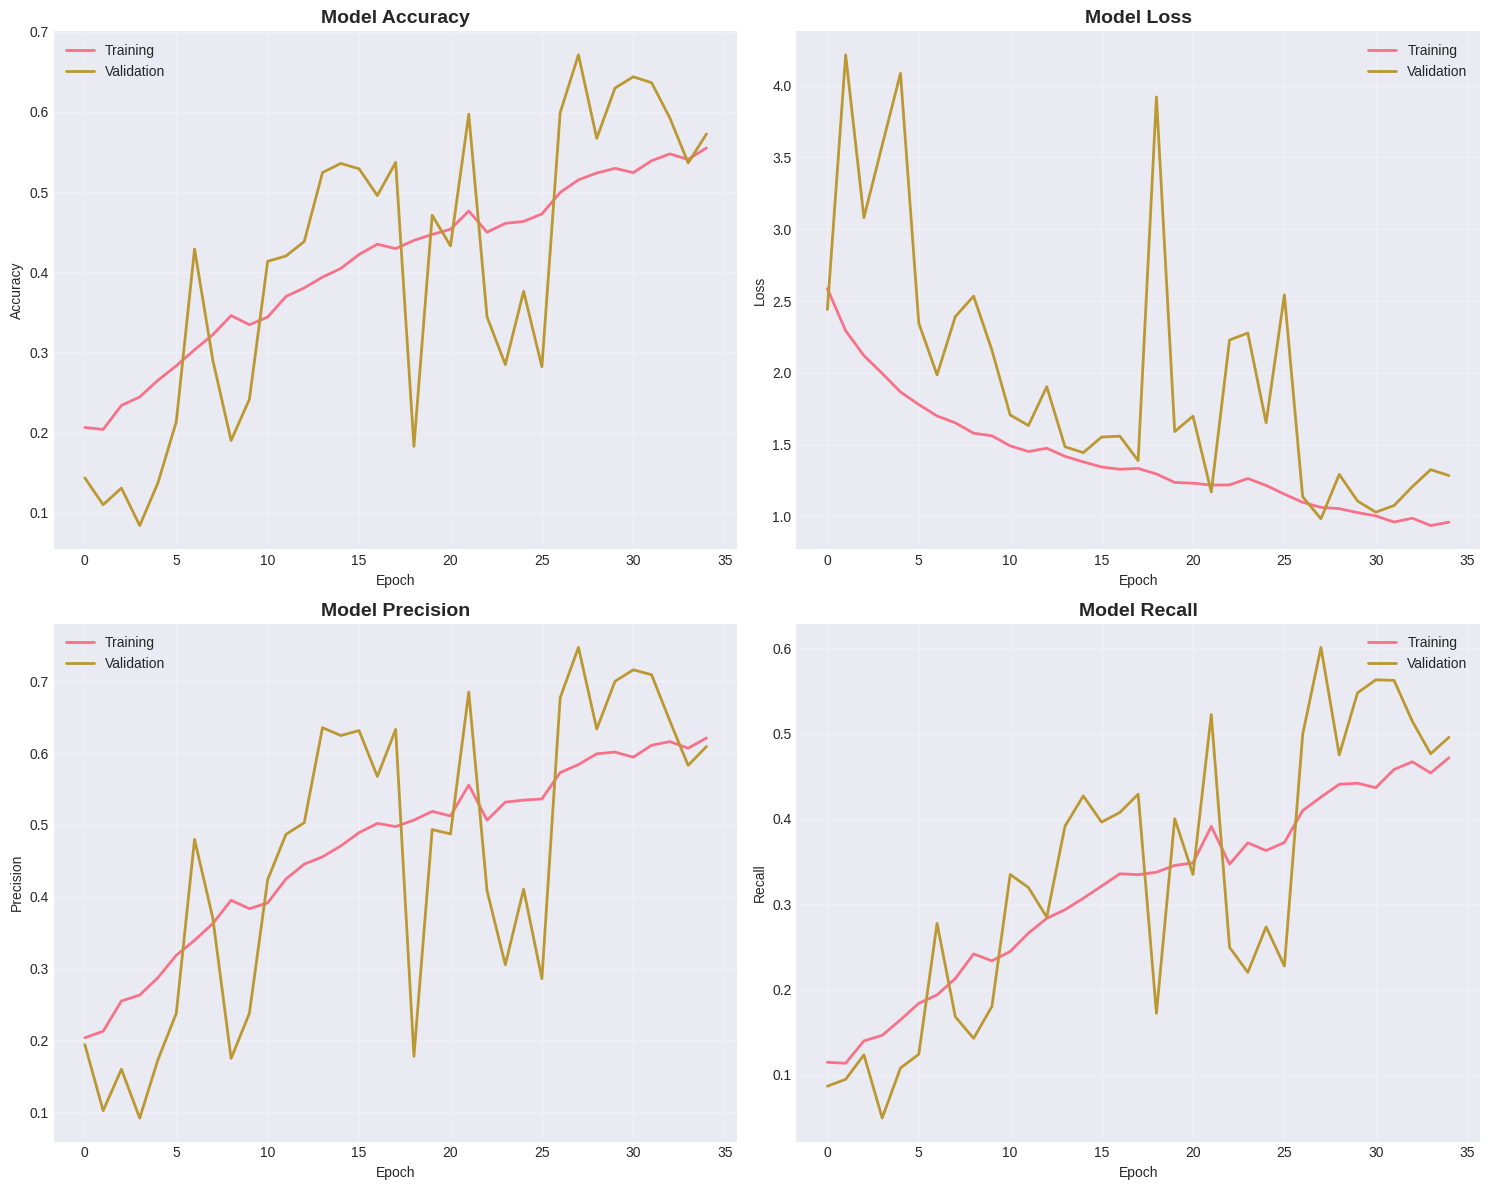

✓ Training history saved!


In [ ]:
# ============================================
# PLOT TRAINING HISTORY
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Training', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Training', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Training', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}/figures/vgg16_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history saved!")

In [ ]:
# ============================================
# EVALUATE ON TEST SET
# ============================================

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

test_results = model_vgg16.evaluate(test_gen, verbose=1)

test_loss = test_results[0]
test_accuracy = test_results[1]
test_precision = test_results[2]
test_recall = test_results[3]
test_auc = test_results[4]
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("\n" + "="*60)
print("🎯 VGG16 TEST RESULTS")
print("="*60)
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print("="*60)


EVALUATING ON TEST SET
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 371ms/step - accuracy: 0.6897 - auc: 0.9256 - loss: 0.9439 - precision: 0.7454 - recall: 0.6032

🎯 VGG16 TEST RESULTS
Test Accuracy:  0.6872 (68.72%)
Test Precision: 0.7447
Test Recall:    0.6070
Test F1-Score:  0.6689
Test AUC:       0.9203


In [ ]:
# ============================================
# GENERATE PREDICTIONS
# ============================================

print("\nGenerating predictions...")

test_gen.reset()
y_pred_proba = model_vgg16.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

print(f"✓ Predictions generated: {len(y_pred)} samples")


Generating predictions...
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step
✓ Predictions generated: 1509 samples


#Confusion Matrix

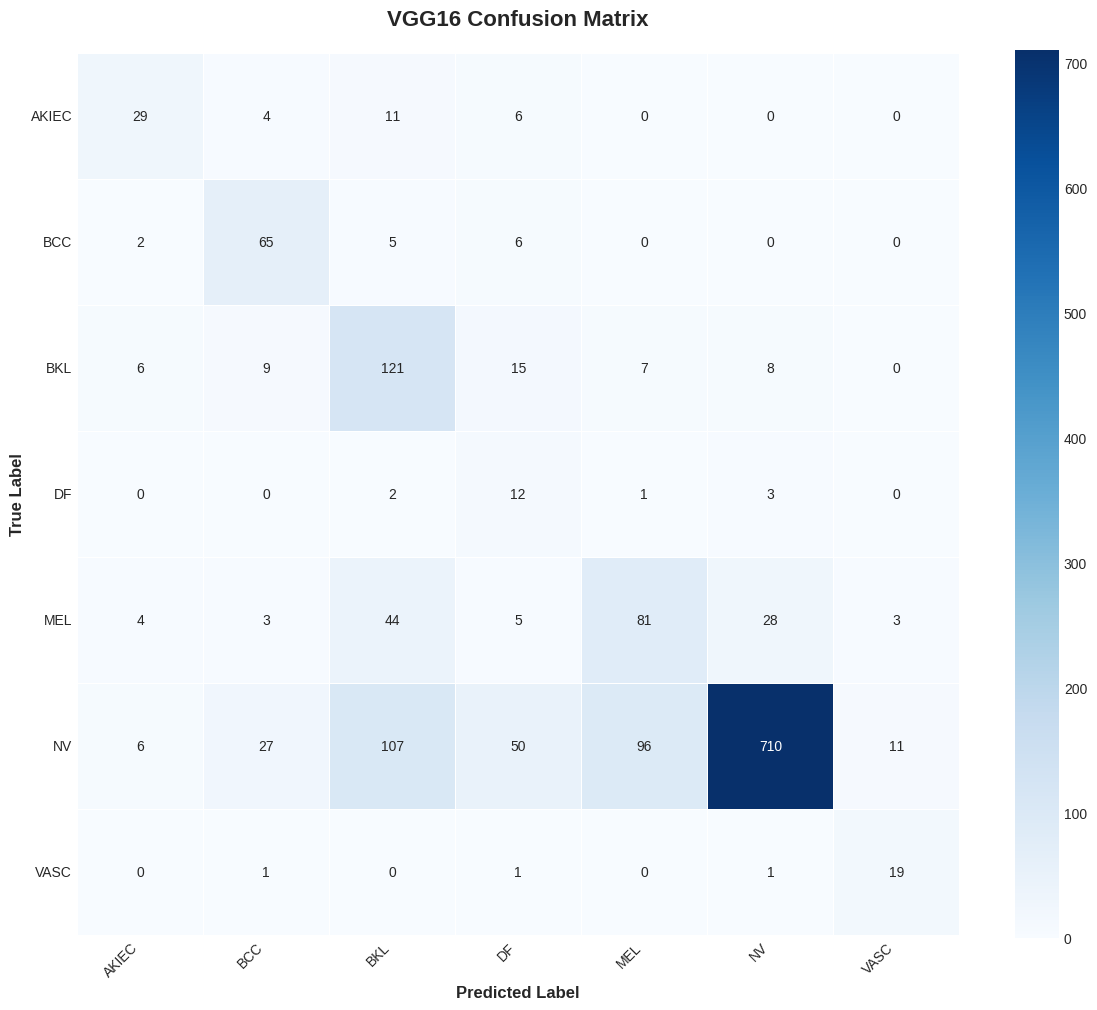

✓ Confusion matrix saved!


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[name.upper() for name in config.CLASS_NAMES],
    yticklabels=[name.upper() for name in config.CLASS_NAMES],
    square=True,
    linewidths=0.5
)

plt.title('VGG16 Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}/figures/vgg16_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved!")

ROC Curves

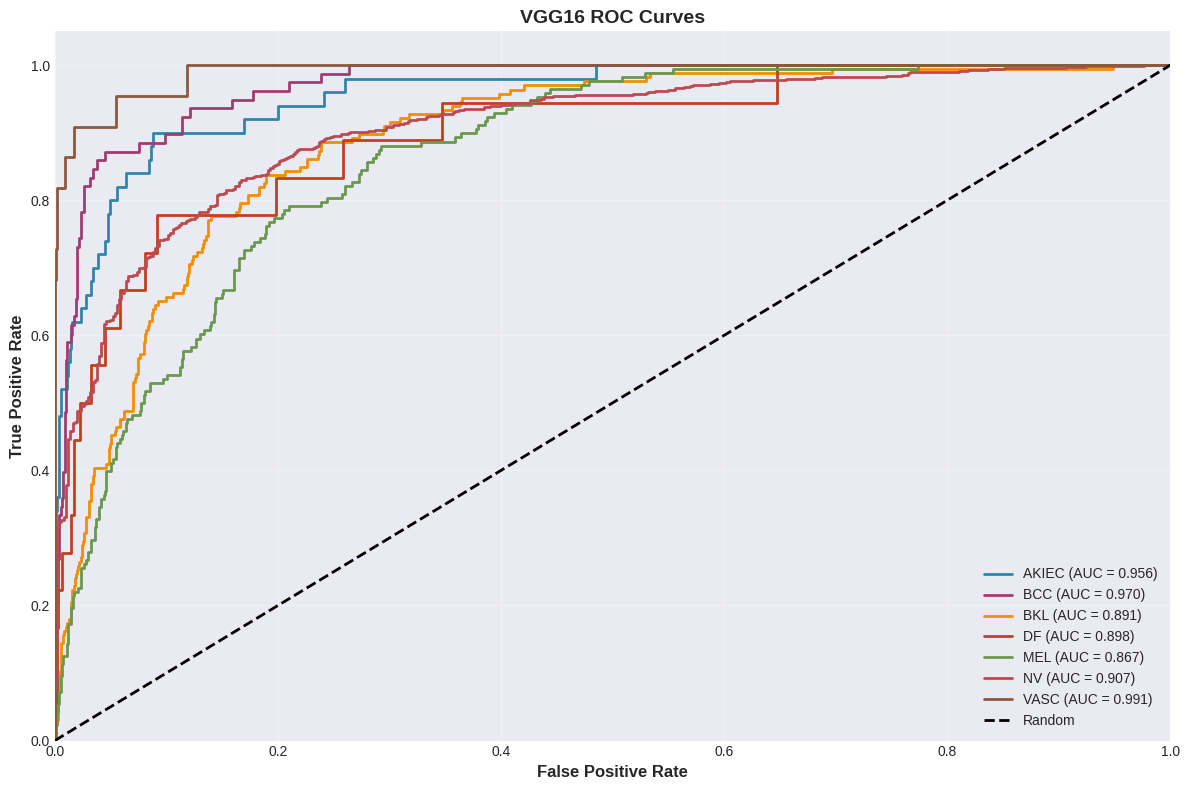

✓ ROC curves saved!


In [ ]:
y_true_bin = label_binarize(y_true, classes=range(config.NUM_CLASSES))

plt.figure(figsize=(12, 8))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51', '#8B5A3C']

for i, (color, class_name) in enumerate(zip(colors, config.CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_name.upper()} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('VGG16 ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}/figures/vgg16_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves saved!")

In [ ]:
# ============================================
# SAVE ALL RESULTS
# ============================================

print("\nSaving all results...")

# Final metrics
final_metrics = {
    'Model': 'VGG16',
    'Test Accuracy': test_accuracy,
    'Test Precision': test_precision,
    'Test Recall': test_recall,
    'Test F1-Score': test_f1,
    'Test AUC': test_auc,
    'Training Time (min)': training_time,
    'Epochs Trained': len(history.history['loss']),
    'Best Val Accuracy': best_val_acc,
    'Best Val Epoch': best_epoch
}

pd.DataFrame([final_metrics]).to_csv(
    f'{config.RESULTS_PATH}/metrics/vgg16_final_metrics.csv',
    index=False
)

# Training history
pd.DataFrame(history.history).to_csv(
    f'{config.RESULTS_PATH}/metrics/vgg16_training_history.csv',
    index=False
)

print("\n" + "="*60)
print("✅ ALL RESULTS SAVED!")
print("="*60)
print(f"📁 Models: {config.PROJECT_DRIVE}/models/")
print(f"📊 Figures: {config.RESULTS_PATH}/figures/")
print(f"📈 Metrics: {config.RESULTS_PATH}/metrics/")
print("="*60)


Saving all results...

✅ ALL RESULTS SAVED!
📁 Models: /content/drive/MyDrive/DeepLearning_Assignment/models/
📊 Figures: /content/drive/MyDrive/DeepLearning_Assignment/results/figures/
📈 Metrics: /content/drive/MyDrive/DeepLearning_Assignment/results/metrics/
